In [ ]:
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import yaml
from matplotlib.gridspec import GridSpec
from tqdm.auto import tqdm
from unseen_awg.weather_generator import WeatherGenerator

In [2]:
mpl.rc_file("../../matplotlibrc")

In [3]:
with open("../../configs/paths.yaml") as file:
    paths = yaml.safe_load(file)["paths"]

In [4]:
path_wg_reforecasts = "wg_reforecasts_5e06172f_f40e9460_1e69bda9"
path_wg_era5 = "wg_era5_f3d1f2f7_6e629cd9_7560715e"

wg = WeatherGenerator.load(os.path.join(paths["dir_wgs"], path_wg_reforecasts))
wg_era = WeatherGenerator.load(os.path.join(paths["dir_wgs"], path_wg_era5))

In [5]:
# test distance to nearest neighbor vs distance to random neighbor for a random subset of points

In [ ]:
def get_n_random_base_samples(
    wg: WeatherGenerator, rng: np.random.Generator, n_samples, lead_time=None
):
    da = wg.ds_similarities.lead_time.load()

    flat_da = da.stack(sdim=da.dims)
    flat_da = flat_da.where(~np.isnan(flat_da), drop=True)

    if lead_time is not None:
        flat_da = flat_da.where(flat_da == lead_time, drop=True)

    random_subset = rng.choice(np.arange(len(flat_da)), size=n_samples, replace=False)
    pseudo_ensemble_member_data = rng.choice(
        wg.ds_similarities.ensemble_member, size=n_samples, replace=True
    )
    return flat_da.isel(sdim=random_subset).assign_coords(
        {"ensemble_member": ("sdim", pseudo_ensemble_member_data)}
    )

In [7]:
n_samples = 1000
k = 10
minimum_timedelta_days = 180

In [ ]:
base_samples_re = get_n_random_base_samples(
    wg=wg, n_samples=n_samples, rng=np.random.default_rng(seed=0)
)
base_samples_era = get_n_random_base_samples(
    wg=wg_era, n_samples=n_samples, rng=np.random.default_rng(seed=0)
)

In [ ]:
sims_neighbors_re = np.sqrt(
    -wg.get_similarities_k_closest_neighbors(
        states=base_samples_re,
        k=k,
        dim_states="sdim",
        minimum_timedelta_days=minimum_timedelta_days,
    )
)
sims_random_re = np.sqrt(
    -wg.get_similarities_k_random_neighbors(
        states=base_samples_re,
        k=k,
        rng=np.random.default_rng(seed=0),
        dim_states="sdim",
        minimum_timedelta_days=minimum_timedelta_days,
    )
)

sims_neighbors_era = np.sqrt(
    -wg_era.get_similarities_k_closest_neighbors(
        states=base_samples_era,
        k=k,
        dim_states="sdim",
        minimum_timedelta_days=minimum_timedelta_days,
    )
)
sims_random_era = np.sqrt(
    -wg_era.get_similarities_k_random_neighbors(
        states=base_samples_era,
        k=k,
        rng=np.random.default_rng(seed=0),
        dim_states="sdim",
        minimum_timedelta_days=minimum_timedelta_days,
    )
)

sims_neighbors_re = sims_neighbors_re.assign_coords(
    {"neighbor": ("neighbor", np.arange(1, k + 1))}
)
sims_random_re = sims_random_re.assign_coords(
    {"neighbor": ("neighbor", np.arange(1, k + 1))}
)

sims_neighbors_era = sims_neighbors_era.assign_coords(
    {"neighbor": ("neighbor", np.arange(1, k + 1))}
)
sims_random_era = sims_random_era.assign_coords(
    {"neighbor": ("neighbor", np.arange(1, k + 1))}
)


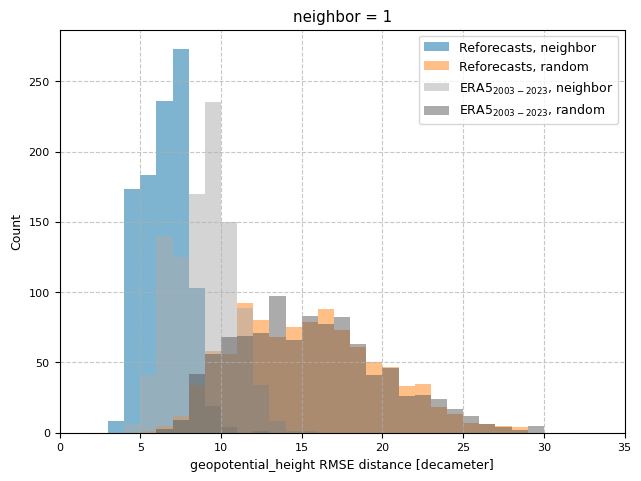

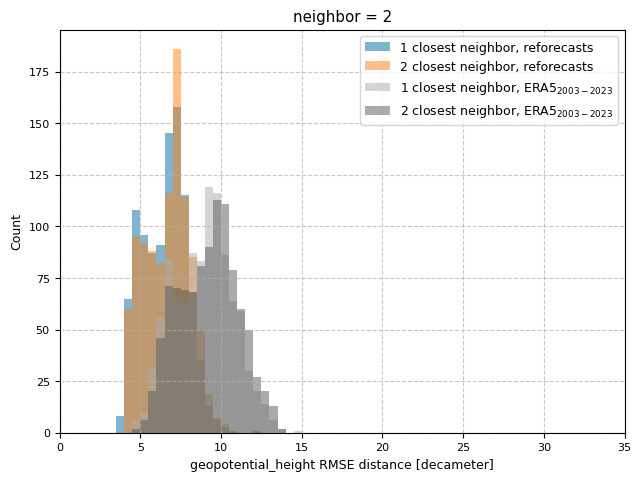

In [10]:
bins = np.linspace(0, 3e1, 31)

bins_nbs_only = np.linspace(0, 1.5e1, 31)

sims_neighbors_re.isel(neighbor=0).plot.hist(
    bins=bins, alpha=0.5, label="Reforecasts, neighbor", histtype="stepfilled"
)
sims_random_re.isel(neighbor=0).plot.hist(
    bins=bins, alpha=0.5, label="Reforecasts, random", histtype="stepfilled"
)

sims_neighbors_era.isel(neighbor=0).plot.hist(
    bins=bins, alpha=0.5, label=r"$\text{ERA5}_{2003-2023}$, neighbor"
)
sims_random_era.isel(neighbor=0).plot.hist(
    bins=bins, alpha=0.5, label=r"$\text{ERA5}_{2003-2023}$, random"
)

plt.ylabel("Count")
plt.xlabel("geopotential_height RMSE distance [decameter]")
plt.legend()
plt.xlim(0, 35)
plt.show()

for i, nb in enumerate(sims_neighbors_re.neighbor.sel(neighbor=slice(1, 2))):
    sims_neighbors_re.sel(neighbor=nb).plot.hist(
        bins=bins_nbs_only,
        alpha=0.5,
        color=f"C{i}",
        label=f"{i + 1} closest neighbor, reforecasts",
    )

n_nbs = 2
for i, nb in enumerate(sims_neighbors_era.neighbor.sel(neighbor=slice(1, n_nbs))):
    sims_neighbors_era.sel(neighbor=nb).plot.hist(
        bins=bins_nbs_only,
        alpha=0.5,
        color=f"C{i + n_nbs}",
        label=f"{i + 1} closest neighbor, " + r"$\text{ERA5}_{2003-2023}$",
    )

plt.ylabel("Count")
plt.xlabel("geopotential_height RMSE distance [decameter]")
plt.xlim(0, 35)
plt.legend()
plt.savefig(os.path.join(paths["dir_images"], "distances_neighbors.png"))

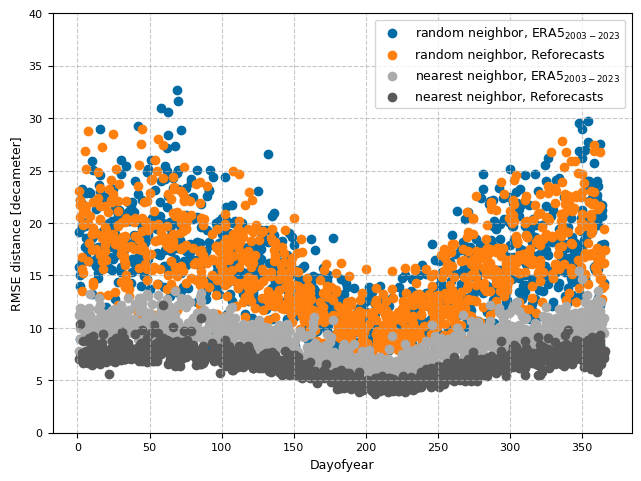

In [11]:
# as a function of the day of year:

plt.scatter(
    sims_random_era.sel(neighbor=1).dayofyear,
    sims_random_era.sel(neighbor=1),
    label=r"random neighbor, $\text{ERA5}_{2003-2023}$",
)
plt.scatter(
    sims_random_re.sel(neighbor=1).dayofyear,
    sims_random_re.sel(neighbor=1),
    label=r"random neighbor, Reforecasts",
)
plt.scatter(
    sims_neighbors_era.sel(neighbor=1).dayofyear,
    sims_neighbors_era.sel(neighbor=1),
    label=r"nearest neighbor, $\text{ERA5}_{2003-2023}$",
)
plt.scatter(
    sims_neighbors_re.sel(neighbor=1).dayofyear,
    sims_neighbors_re.sel(neighbor=1),
    label=r"nearest neighbor, Reforecasts",
)
plt.ylim(0, 40)
plt.xlabel("Dayofyear")
plt.ylabel("RMSE distance [decameter]")
plt.legend()
plt.savefig(os.path.join(paths["dir_images"], "distances_neighbors_climatology.png"))

In [12]:
from unseen_awg.preprocessing.compute_climatology import interpolate_then_rolling_mean

In [13]:
half_window_size = 20
means_doy_re = sims_neighbors_re.sel(neighbor=1).groupby("dayofyear").mean()
annual_cycle_re = interpolate_then_rolling_mean(
    means_doy_re, half_window_size=half_window_size
)

means_doy_era = sims_neighbors_era.sel(neighbor=1).groupby("dayofyear").mean()
annual_cycle_era = interpolate_then_rolling_mean(
    means_doy_era, half_window_size=half_window_size
)

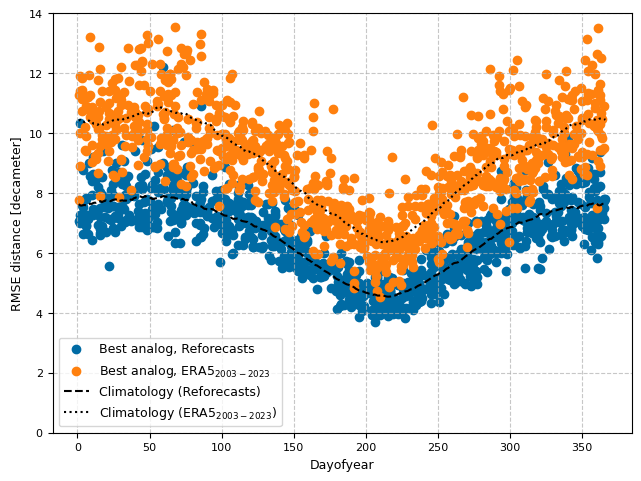

In [14]:
plt.scatter(
    sims_neighbors_re.sel(neighbor=1).dayofyear,
    sims_neighbors_re.sel(neighbor=1),
    label=r"Best analog, Reforecasts",
)
plt.scatter(
    sims_neighbors_era.sel(neighbor=1).dayofyear,
    sims_neighbors_era.sel(neighbor=1),
    label=r"Best analog, $\mathrm{ERA5}_{2003-2023}$",
)

annual_cycle_re.plot(color="k", linestyle="dashed", label="Climatology (Reforecasts)")
annual_cycle_era.plot(
    color="k", linestyle="dotted", label=r"Climatology ($\mathrm{ERA5}_{2003-2023}$)"
)

plt.title("")
plt.ylim(0, 14)
plt.xlabel("Dayofyear")
plt.ylabel("RMSE distance [decameter]")
plt.legend()

We are interested in the following distances:

![](../../images/illustration_analogue_distances.jpg)

$\vec{v}$ is the distance between consecutive pressure patterns at $t$ and $t+1$. $\vec{d_n}$ is a typical distance between two samples from an $n$-day forecast, and $a_i$ is the distance to the i-th nearest neighbor of $t+1$ to the circulation at $t+1$.

In this notebook, so far we've computed $||\vec{a_i}||$ for the $n_{neighbors}$ nearest neighbors, and compared this with the distance between random patterns for both re-forecast and ERA5 data sets.

($||\cdot||$ is the Euclidean distance).

there are however a few other interesting metrics:
e.g. $M^{(i, n)} = \frac{||\vec{a_i}||}{d_n}$

to compute this we need to load a few more things:

### computing $d_n$ for the reforecast WG
($d_n$ isn't defined for ERA5).

Tried computing it via the sigma / mu methodology making strong assumptions of the distribution within this ensemble but that doesn't work out, probably because the fundamental assumptions aren't fulfilled.

In [15]:
n_samples = 1000
lts = np.arange(0, 20, 1) * np.timedelta64(1, "D")

In [ ]:
def random_other_member(arr, q, rng):
    return rng.choice(arr[arr != q], size=1)


similarities_ens = []
similarities_ens_mean = []
for lt in tqdm(lts):
    base_samples_lt = get_n_random_base_samples(
        wg, n_samples=n_samples, lead_time=lt, rng=np.random.default_rng(seed=0)
    )
    other_ensemble_member = xr.apply_ufunc(
        random_other_member,
        wg.ds_similarities.ensemble_member.load(),
        base_samples_lt.ensemble_member,
        np.random.default_rng(seed=0),
        input_core_dims=[["ensemble_member"], [], []],
        output_core_dims=[[]],
        vectorize=True,
    )

    sims = np.sqrt(
        -wg.ds_similarities.similarities.sel(
            dayofyear=base_samples_lt.dayofyear,
            year=base_samples_lt.year,
            sample=base_samples_lt.sample,
            ensemble_member=base_samples_lt.ensemble_member,
            d_shift=0
            * base_samples_lt.dayofyear,  # hacky way to get a array of zeros with right shape
            c_year=base_samples_lt.year,
            c_sample=base_samples_lt.sample,
            c_ensemble_member=other_ensemble_member,
        ).load()
    )
    similarities_ens.append(sims.quantile([0.05, 0.95]).expand_dims(lead_time=[lt]))
    similarities_ens_mean.append(sims.mean().expand_dims(lead_time=[lt]))

similarities_ens = xr.combine_by_coords(similarities_ens)
similarities_ens_mean = xr.combine_by_coords(similarities_ens_mean)

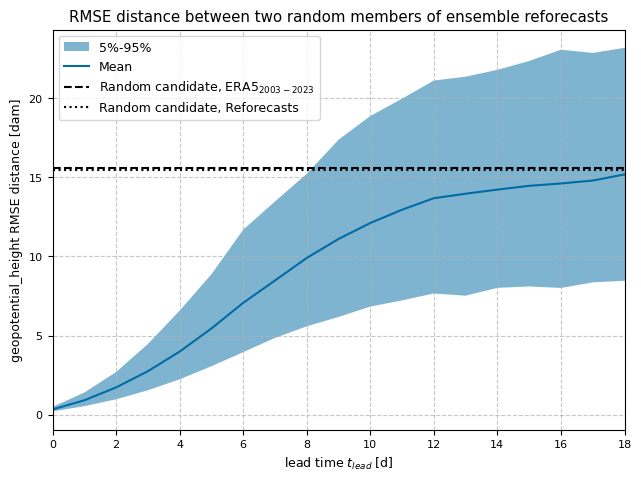

In [17]:
plt.fill_between(
    similarities_ens.lead_time / np.timedelta64(1, "D"),
    similarities_ens.similarities.sel(quantile=0.05),
    similarities_ens.similarities.sel(quantile=0.95),
    alpha=0.5,
    label="5%-95%",
)
plt.plot(
    similarities_ens_mean.lead_time / np.timedelta64(1, "D"),
    similarities_ens_mean.similarities,
    label="Mean",
)

plt.axhline(
    sims_random_era.isel(neighbor=0).mean(),
    label=r"Random candidate, $\text{ERA5}_{2003-2023}$",
    color="k",
    linestyle="dashed",
)

plt.axhline(
    sims_random_re.isel(neighbor=0).mean(),
    label="Random candidate, Reforecasts",
    color="k",
    linestyle="dotted",
)

plt.xlim(0, 18)
plt.xlabel(r"lead time $t_{lead}$ [d]")
plt.ylabel("geopotential_height RMSE distance [dam]")
plt.title("RMSE distance between two random members of ensemble reforecasts")

plt.legend()
plt.savefig(
    os.path.join(paths["dir_images"], "mean_distance_two_random_ensemble_members.png")
)

In [18]:
s_ens = similarities_ens_mean.expand_dims(neighbor=sims_neighbors_re.neighbor)
s_re = sims_neighbors_re.mean("sdim").expand_dims(
    lead_time=similarities_ens_mean.lead_time
)
s_era = sims_neighbors_era.mean("sdim").expand_dims(
    lead_time=similarities_ens_mean.lead_time
)

s_ens["lead_time"] = s_ens["lead_time"] / np.timedelta64(1, "D")
s_re["lead_time"] = s_re["lead_time"] / np.timedelta64(1, "D")
s_era["lead_time"] = s_era["lead_time"] / np.timedelta64(1, "D")

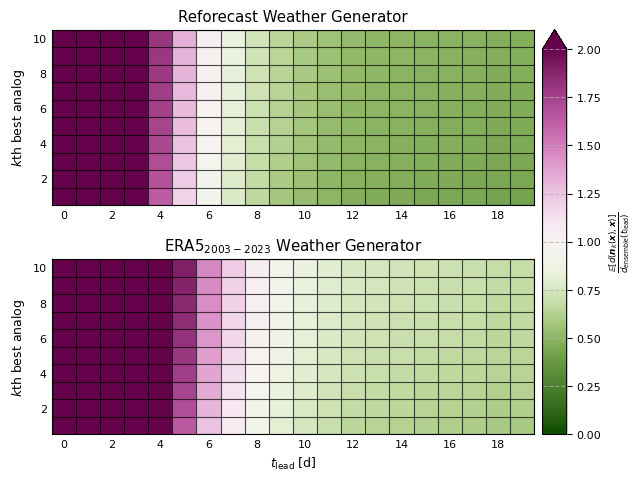

In [19]:
fig = plt.figure()

gs = GridSpec(2, 2, figure=fig, width_ratios=[1, 0.05])

ax_cbar = fig.add_subplot(gs[:, -1])

ax_re = fig.add_subplot(gs[0, 0])
(s_re / s_ens).transpose().similarities.plot(
    ax=ax_re,
    cmap="cmc.bam_r",
    vmin=0,
    vmax=2,
    cbar_ax=ax_cbar,
    cbar_kwargs={
        "orientation": "vertical",
        "label": r"$\frac{\mathbb{E}[d(\boldsymbol{n}_k(\boldsymbol{x}), \boldsymbol{x})]}{d_{\text{ensemble}}(t_\mathrm{lead})}$",
    },
)
ax_re.set_xlabel("")
ax_re.set_ylabel(r"$k$th best analog")
ax_re.set_title("Reforecast Weather Generator")
ax_re.set_xticks(np.arange(0, 20, 2))

ax_re.set_xticks(np.arange(-0.5, len(s_ens.lead_time), 1), minor=True)
ax_re.set_yticks(np.arange(0.5, len(s_re.neighbor) + 1, 1), minor=True)
ax_re.grid(which="minor", color="black", linestyle="-")
ax_re.tick_params(which="major", length=0)  # Hide major tick marks

ax_re.tick_params(which="major", length=0)
ax_re.tick_params(which="minor", length=0)


ax_era = fig.add_subplot(gs[1, 0])
(s_era / s_ens).transpose().similarities.plot(
    ax=ax_era, cmap="cmc.bam_r", vmin=0, vmax=2, add_colorbar=False
)
ax_era.set_title(r"$\mathrm{ERA5}_{2003-2023}$ Weather Generator")
ax_era.set_xlabel(r"$t_\mathrm{lead}$ [d]")
ax_era.set_ylabel(r"$k$th best analog")
ax_era.set_xticks(np.arange(0, 20, 2))


ax_era.set_xticks(np.arange(-0.5, len(s_ens.lead_time), 1), minor=True)
ax_era.set_yticks(np.arange(0.5, len(s_era.neighbor) + 1, 1), minor=True)
ax_era.grid(which="minor", color="black", linestyle="-")
ax_era.tick_params(which="major", length=0)
ax_era.tick_params(which="minor", length=0)


plt.savefig(
    os.path.join(paths["dir_images"], "distances_neighbors_summary.pdf"), dpi=300
)

In [20]:
print("neigbor reforecasts: ", sims_neighbors_re.sel(neighbor=1).mean().data)
print("random reforecasts: ", sims_random_re.mean().data)
print("neigbor ERA5: ", sims_neighbors_era.sel(neighbor=1).mean().data)
print("random ERA5: ", sims_random_era.mean().data)

neigbor reforecasts:  6.502876860101685
random reforecasts:  15.389062058623976
neigbor ERA5:  8.940774189710211
random ERA5:  15.560463680216726


In [21]:
# get confidence intervals through bootstrapping:
from scipy.stats import bootstrap

In [22]:
np.isnan(sims_random_era.stack(ssdim=("sdim", "neighbor"))).any()

<xarray.DataArray 'similarities' ()> Size: 1B
array(False)
Attributes:
    long_name:  similarity score between forecast and candidate analog
    units:      1

In [23]:
for name, da in zip(
    [
        "neigbor reforecasts",
        "random reforecasts",
        "neigbor ERA5 (2003-2023)",
        "random ERA5 (2003-2023)",
    ],
    [
        sims_neighbors_re.sel(neighbor=1),
        sims_random_re.stack(ssdim=("sdim", "neighbor")),
        sims_neighbors_era.sel(neighbor=1),
        sims_random_era.stack(ssdim=("sdim", "neighbor")),
    ],
):
    res = bootstrap(
        da.expand_dims({"dim": [0]}), np.nanmean, rng=np.random.default_rng(seed=0)
    )
    print(
        name,
        f"{da.mean().data:.2f}",
        f"{res.confidence_interval.low:.2f}, {res.confidence_interval.high:.2f}",
    )

neigbor reforecasts 6.50 6.42, 6.59


random reforecasts 15.39 15.30, 15.48
neigbor ERA5 (2003-2023) 8.94 8.83, 9.05
random ERA5 (2003-2023) 15.56 15.47, 15.65


## how many re-forecast nearest neighbors are closer than ERA5 nearest neighbor?

In [24]:
n_samples = 1000
k = 10_000
minimum_timedelta_days = 180

In [25]:
base_samples_re = get_n_random_base_samples(
    wg=wg, n_samples=n_samples, rng=np.random.default_rng(seed=0)
)
base_samples_era = get_n_random_base_samples(
    wg=wg_era, n_samples=n_samples, rng=np.random.default_rng(seed=0)
)

In [26]:
sims_neighbors_re = np.sqrt(
    -wg.get_similarities_k_closest_neighbors(
        states=base_samples_re,
        k=k,
        dim_states="sdim",
        minimum_timedelta_days=minimum_timedelta_days,
    )
)

sims_neighbors_era = np.sqrt(
    -wg_era.get_similarities_k_closest_neighbors(
        states=base_samples_era,
        k=1,
        dim_states="sdim",
        minimum_timedelta_days=minimum_timedelta_days,
    )
)

sims_neighbors_re = sims_neighbors_re.assign_coords(
    {"neighbor": ("neighbor", np.arange(1, k + 1))}
)
sims_neighbors_era = sims_neighbors_era.assign_coords(
    {"neighbor": ("neighbor", np.arange(1, 2))}
)

/gpfs1/schlecker/home/wider/Projects/unseen-awg/src/unseen_awg/weather_generator.py:939: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'sdim'} to avoid an error in the future.
  sims = self.ds_similarities.sel(


/gpfs1/schlecker/home/wider/Projects/unseen-awg/src/unseen_awg/weather_generator.py:939: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'sdim'} to avoid an error in the future.
  sims = self.ds_similarities.sel(


In [27]:
mean_sim_closest_neighbor_era = sims_neighbors_era.squeeze()

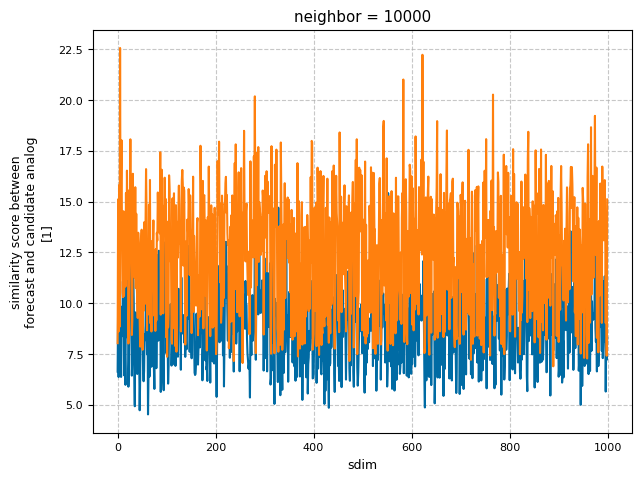

In [28]:
sims_neighbors_era.squeeze().plot()

sims_neighbors_re.isel(neighbor=-1).squeeze().plot()

# sims_neighbors_re.isel(neighbor=0).squeeze().plot()

In [29]:
(sims_neighbors_re < mean_sim_closest_neighbor_era).sum("neighbor").median()

<xarray.DataArray 'similarities' ()> Size: 8B
array(301.)
Attributes:
    long_name:  similarity score between forecast and candidate analog
    units:      1

in conclusion: in half the cases, we find 300 better analogs in the reforecast dataset than the best one in the ERA5 dataset.